In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [2]:
# Warning suppression
import warnings
warnings.filterwarnings(
    "ignore",
    message="The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.",
    category=UserWarning,
    module="cartopy.mpl.geoaxes"
)

In [3]:
def plot_exps(clusters,titles,plev):

    varnames=['u','v']
    nrows=2
    ncols=2
    #plev=200
    #plev=850
    #clevs=np.arange(-10,11,1)
    clevs=np.arange(-3,3.5,0.5)
    #ccolor='RdGy_r'
    ccolor='RdYlBu_r'
    
    for v in varnames:
    
        f, axs = pplt.subplots(nrows=nrows, ncols=ncols, span=False, proj='pcarree',
                               proj_kw={'central_longitude': 210},
                               figsize=(11.0, 8.5),
                               sharex=False, sharey=False)
        axs.format(abcloc='l', abc='(a)',
                   latlines=10,     # Draw latitude lines every 15°
                   lonlines=30,     # Draw longitude lines every 30°
                   latlabels=True,  # Show latitude labels
                   lonlabels=True   # Show longitude labels
        )
        for ax, cluster, title in zip(axs, clusters, titles):

            cs = ax.contourf(cluster['lon'].values, cluster['lat'].values,
                             cluster[v].sel(lev=plev).values,
                             norm='div', levels=clevs, cmap=ccolor, extend='both',
                             labels=False, labels_kw={'fontsize': 'large'})
            ax.format(
                title=title,
                reso='lo', coast=True, borders=True,
                coastcolor='black', borderscolor='black',
                innerborders=False, 
                latlim=latreg, lonlim=lonreg,
                lonlabels='b', latlabels='l',
                latlines=20, lonlines=30,
                grid=True,# to show gridlines
                fontsize=14,  # Larger title and labels
                titleweight='bold',  # Make the title bold
                labelweight='bold',  # Make axis labels bold
                linewidth=2,  # Make map frame bold
                )



        # Add colorbar at the bottom
        f.colorbar(cs, loc='b', length=0.6, label="ms-1")
        #f.savefig('nps_pacific_to_useast.png', dpi=300)


In [4]:
def plot_exps_clusters(clusters,titles,suptitle):

    varnames=['u','v']
    nrows=4
    ncols=2
    #plev=200
    plev=850
    #clevs=np.arange(-2,2.5,0.5)
    clevs=np.arange(-10,11,1)
    ccolor='RdGy_r'

    f, axs = pplt.subplots(nrows=nrows, ncols=ncols, span=False, proj='pcarree',
                           proj_kw={'central_longitude': 210},
                           figsize=(11.0, 8.5),
                               sharex=False, sharey=False)
    axs.format(abcloc='l', abc='(a)',
               latlines=10,     # Draw latitude lines every 15°
               lonlines=30,     # Draw longitude lines every 30°
               latlabels=True,  # Show latitude labels
               lonlabels=True,   # Show longitude labels
               suptitle=suptitle)

    for i,v in enumerate(varnames):
    
        for j,(cluster, title) in enumerate(zip(clusters, titles)):

            cs = axs[j,i].contourf(cluster['lon'].values, cluster['lat'].values,
                             cluster[v].sel(lev=plev).values,
                             norm='div', levels=clevs, cmap=ccolor, extend='both',
                             labels=False, labels_kw={'fontsize': 'large'})
            axs[j,i].format(
                            title=title,
                            reso='lo', coast=True, borders=True,
                            coastcolor='black', borderscolor='black',
                            innerborders=False, 
                            latlim=latreg, lonlim=lonreg,
                            lonlabels='b', latlabels='l',
                            latlines=20, lonlines=30,
                            grid=True,# to show gridlines
                            fontsize=14,  # Larger title and labels
                            titleweight='bold',  # Make the title bold
                            labelweight='bold',  # Make axis labels bold
                            linewidth=2,  # Make map frame bold
                            )



    # Add colorbar at the bottom
    f.colorbar(cs, loc='b', length=0.6, label="ms-1")
    #f.savefig('nps_pacific_to_useast.png', dpi=300)


In [5]:
expnames=['cluster4_ANA_1979-2023']
basepath='/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/'
DataSetname = ['uvel','vvel','geo']
Dataname = ['u','v','geo']
latreg=[-20,80]
lonreg=[60,350]

### Get all the Experiments

In [7]:
ds_exps_list=[]
for e in expnames:
    datapath=basepath+'T63L26_'+e+'/'
    ds_list=[]
    for dsn,dn in zip(DataSetname,Dataname):
        fnames=datapath+dsn+'_Pressure_days_1-30.nc'
        print(fnames)
        ds=xr.open_mfdataset(fnames,combine='by_coords')
        ds_list.append(ds)
    ds_all=xr.merge(ds_list)  
    ds_exps_list.append(ds_all)
ds_exps=xr.combine_nested(ds_exps_list,concat_dim='exp')
ds_exps['exp']=expnames

/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_cluster4_ANA_1979-2023/uvel_Pressure_days_1-30.nc


/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_cluster4_ANA_1979-2023/vvel_Pressure_days_1-30.nc
/data/esplab/kpegion/projects/AGCM/MultiThread_Model/experiments/T63L26_cluster4_ANA_1979-2023/geo_Pressure_days_1-30.nc


In [8]:
ds_exps_means=ds_exps.mean(dim='time')

In [9]:
ds_exps_means

<xarray.Dataset>
Dimensions:  (exp: 1, lev: 4, lat: 96, lon: 192)
Coordinates:
  * lev      (lev) float64 850.0 500.0 300.0 200.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * exp      (exp) <U22 'cluster4_ANA_1979-2023'
Data variables:
    u        (exp, lev, lat, lon) float64 dask.array<chunksize=(1, 4, 96, 192), meta=np.ndarray>
    v        (exp, lev, lat, lon) float64 dask.array<chunksize=(1, 4, 96, 192), meta=np.ndarray>
    geo      (exp, lev, lat, lon) float64 dask.array<chunksize=(1, 4, 96, 192), meta=np.ndarray>

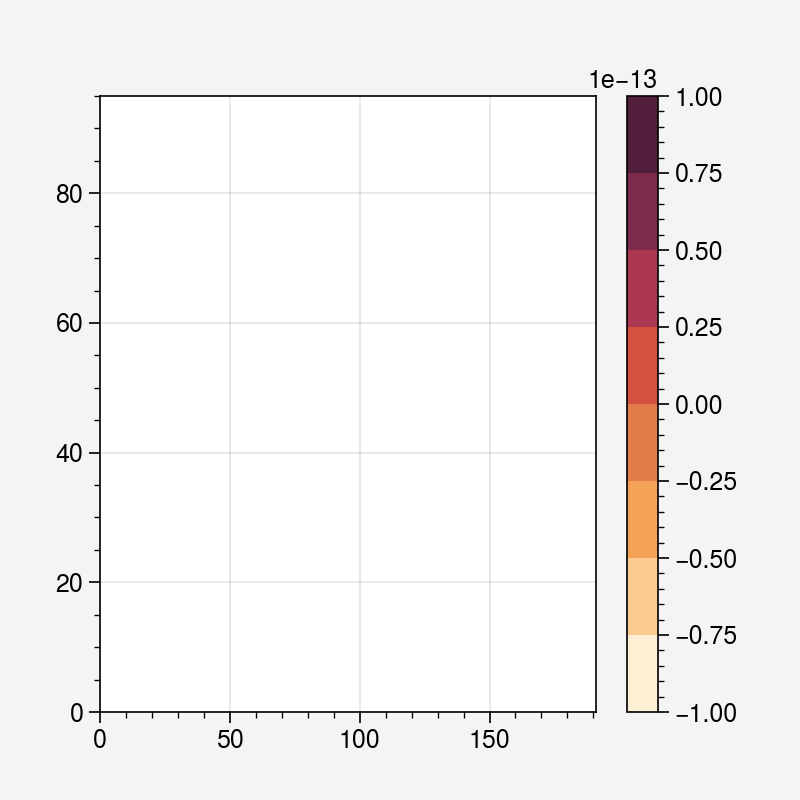

In [12]:
plt.contourf(ds_exps_means['geo'].sel(lev=200.0,exp='cluster4_ANA_1979-2023'))
plt.colorbar()

### Difference between each cluster and CNTRL

In [9]:
diff_cluster4=ds_exps_means.sel(exp=expnames[1])-ds_exps_means.sel(exp=expnames[0])

In [12]:
diff_cluster4

<xarray.Dataset>
Dimensions:  (lev: 4, lat: 96, lon: 192)
Coordinates:
  * lev      (lev) float64 850.0 500.0 300.0 200.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
Data variables:
    u        (lev, lat, lon) float64 dask.array<chunksize=(4, 96, 192), meta=np.ndarray>
    v        (lev, lat, lon) float64 dask.array<chunksize=(4, 96, 192), meta=np.ndarray>
    geo      (lev, lat, lon) float64 dask.array<chunksize=(4, 96, 192), meta=np.ndarray>

In [17]:
tmp=ds_exps.sel(exp='cluster4_ANA_1979-2023',lev=200).isel(time=0)

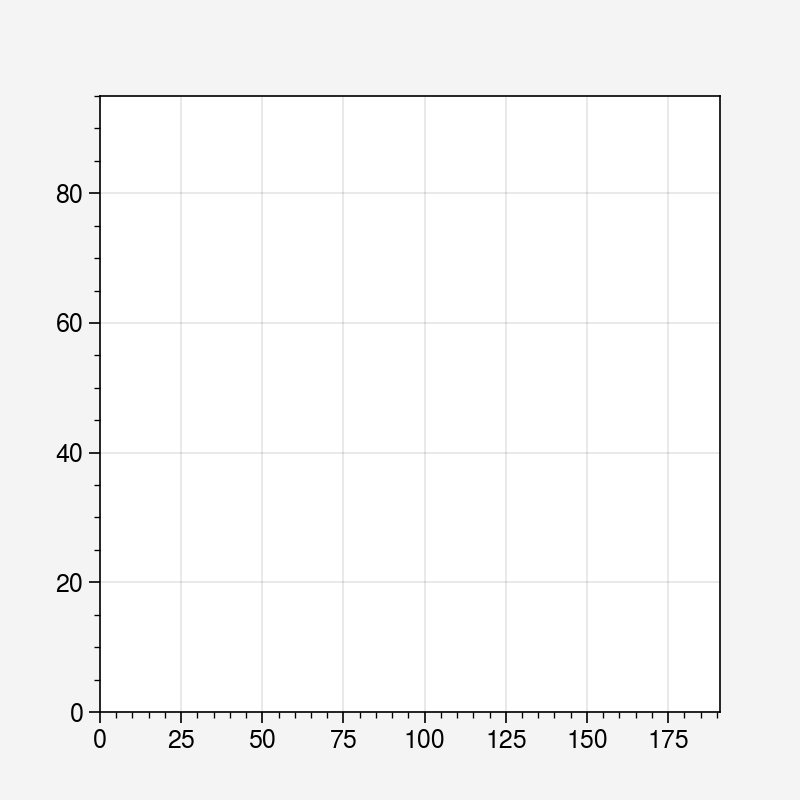

In [18]:
plt.contourf(tmp['v'])

### Plot U200 and V200 for these differences

/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/matplotlib/contour.py:1430: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/matplotlib/contour.py:1431: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())
/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1614: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/matplotlib/contour.py:1430: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/matplotlib/contour.py:1431: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())
/home/kpegion/miniconda3/envs/su

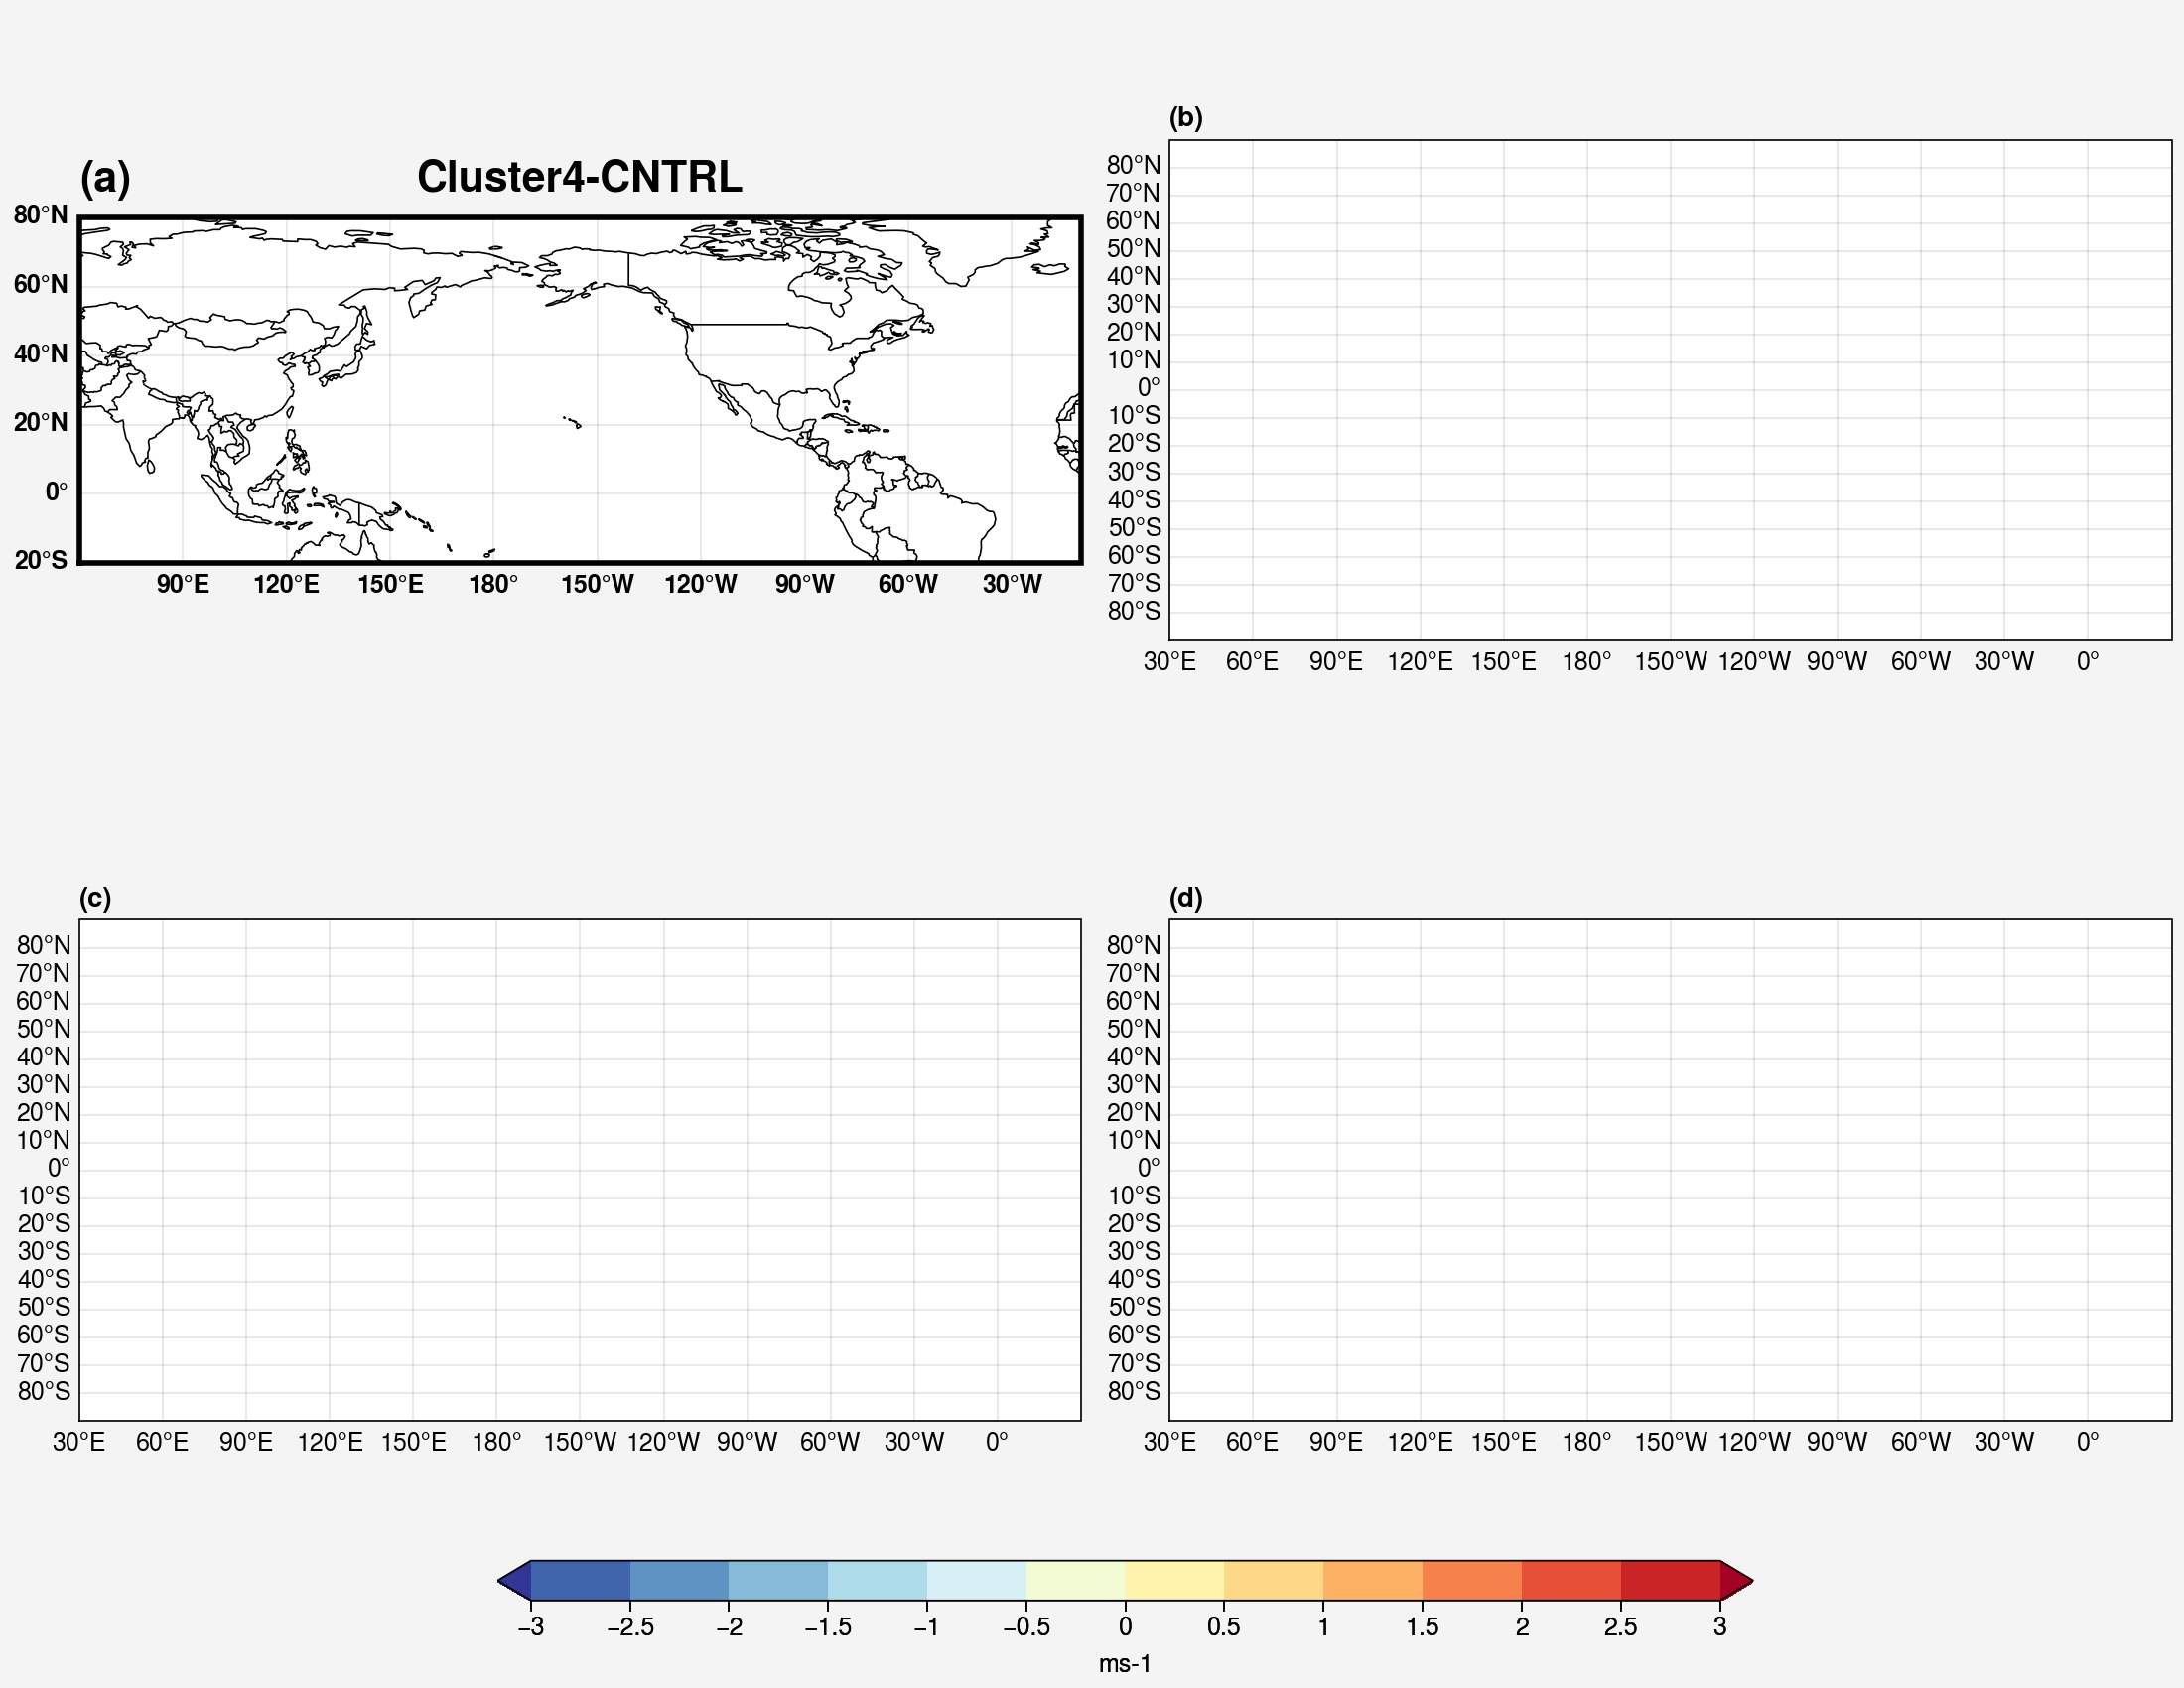

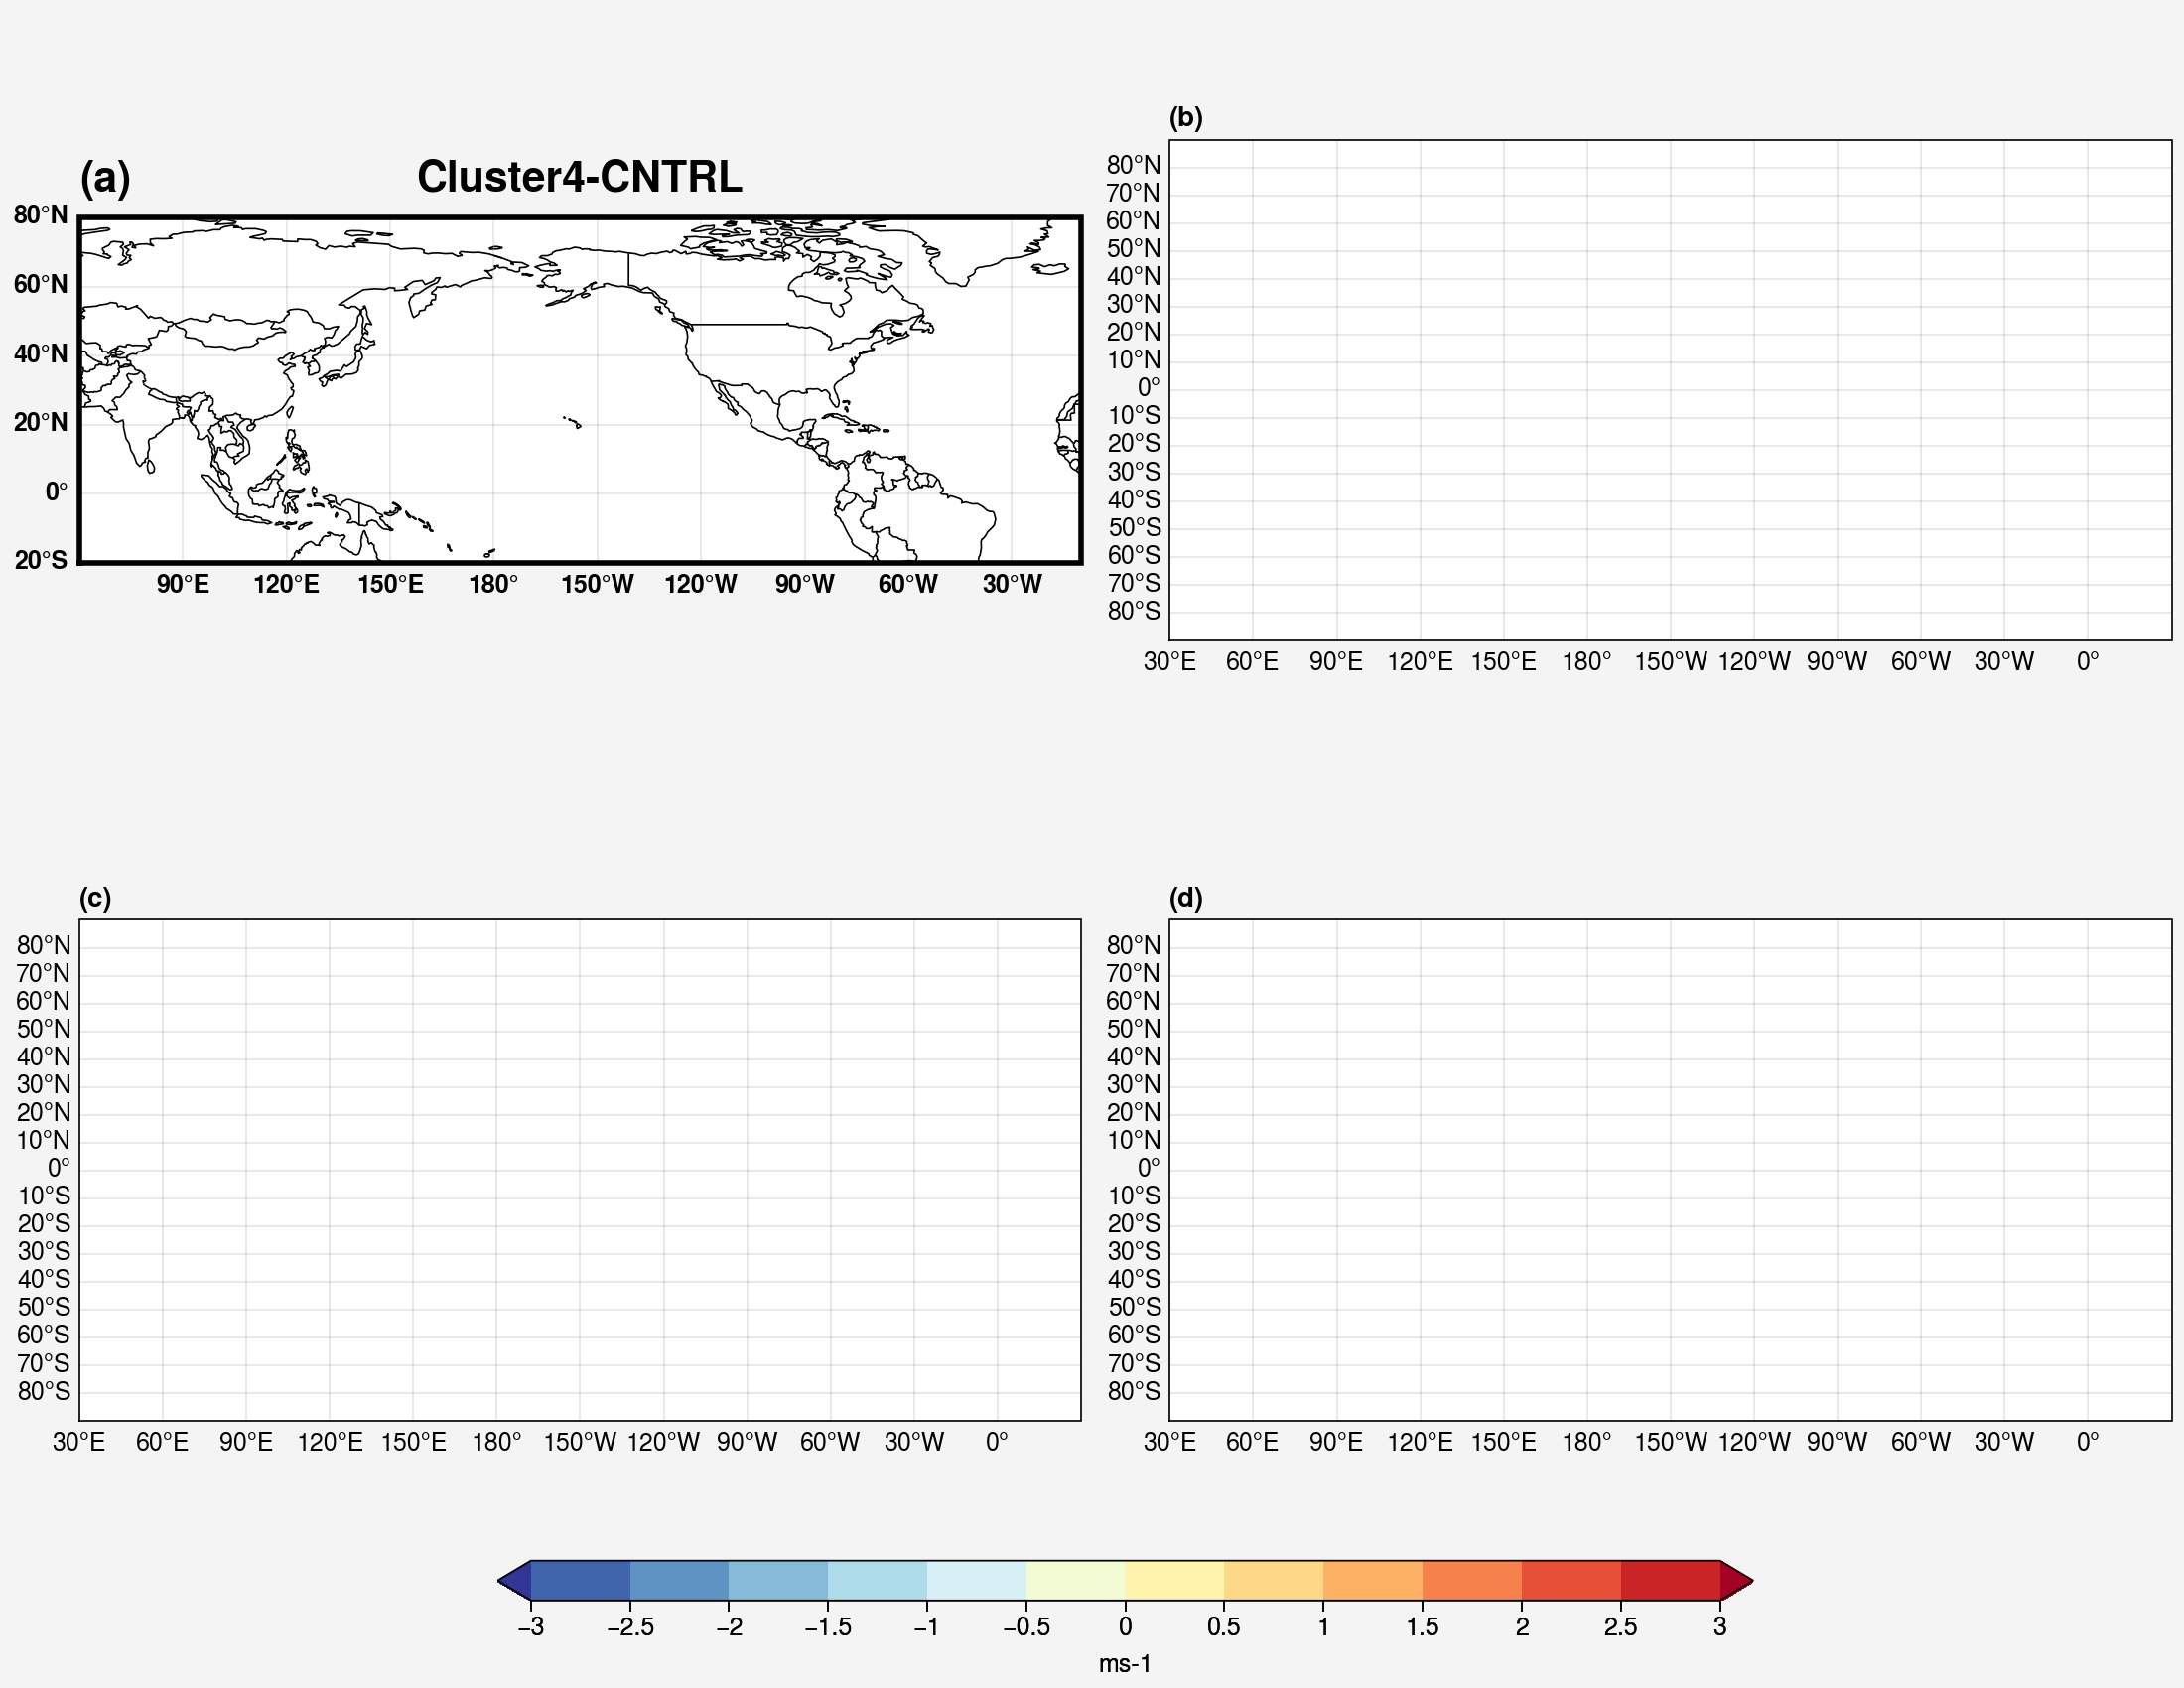

In [10]:
clusters = [diff_cluster4] #, diff_cluster2, diff_cluster3, diff_cluster4]
titles = ['Cluster4-CNTRL'] #, 'Cluster2-CNTRL', 'Cluster3-CNTRL', 'Cluster4-CNTRL']
#plot_exps(clusters,titles,850)
plot_exps(clusters,titles,200)

In [ ]:
expnames=['HeatingJJA_1979-2023', 'Cluster1_ANA_1979-2023_', 'Cluster2_ANA_1979-2023_', 
         'Cluster3_ANA_1979-2023_', 'Cluster4_ANA_1979-2023_']
ds_exps_list=[]
for e in expnames:
    datapath=basepath+'T63L26_'+e+'/'
    ds_list=[]
    for dsn,dn in zip(DataSetname,Dataname):
        fnames=datapath+dsn+'_Pressure_days_1-*.nc'
        print(fnames)
        ds=xr.open_mfdataset(fnames,combine='by_coords')
        ds_list.append(ds)
    ds_all=xr.merge(ds_list)  
    ds_exps_list.append(ds_all)
ds_exps=xr.combine_nested(ds_exps_list,concat_dim='exp')
ds_exps['exp']=expnames
ds_exps_means=ds_exps.mean(dim='time')
diff_cluster1=ds_exps_means.sel(exp=expnames[1])-ds_exps_means.sel(exp=expnames[0])
diff_cluster2=ds_exps_means.sel(exp=expnames[2])-ds_exps_means.sel(exp=expnames[0])
diff_cluster3=ds_exps_means.sel(exp=expnames[3])-ds_exps_means.sel(exp=expnames[0])
diff_cluster4=ds_exps_means.sel(exp=expnames[4])-ds_exps_means.sel(exp=expnames[0])

clusters = [diff_cluster1, diff_cluster2, diff_cluster3, diff_cluster4]
titles = ['Cluster1-CNTRL', 'Cluster2-CNTRL', 'Cluster3-CNTRL', 'Cluster4-CNTRL']
#plot_exps(clusters,titles,850)
plot_exps(clusters,titles,200)

In [ ]:
expnames=['HeatingJJA', 'Cluster1_ANA', 'ANA', 
         'Cluster3_ANA', 'Cluster4_ANA']
ds_exps_list=[]
for e in expnames:
    datapath=basepath+'T63L26_'+e+'/'
    ds_list=[]
    for dsn,dn in zip(DataSetname,Dataname):
        fnames=datapath+dsn+'_Pressure_days_1-*.nc'
        print(fnames)
        ds=xr.open_mfdataset(fnames,combine='by_coords')
        ds_list.append(ds)
    ds_all=xr.merge(ds_list)  
    ds_exps_list.append(ds_all)
ds_exps=xr.combine_nested(ds_exps_list,concat_dim='exp')
ds_exps['exp']=expnames
ds_exps_means=ds_exps.mean(dim='time')
diff_cluster1=ds_exps_means.sel(exp=expnames[1])-ds_exps_means.sel(exp=expnames[0])
diff_cluster2=ds_exps_means.sel(exp=expnames[2])-ds_exps_means.sel(exp=expnames[0])
diff_cluster3=ds_exps_means.sel(exp=expnames[3])-ds_exps_means.sel(exp=expnames[0])
diff_cluster4=ds_exps_means.sel(exp=expnames[4])-ds_exps_means.sel(exp=expnames[0])

clusters = [diff_cluster1, diff_cluster2, diff_cluster3, diff_cluster4]
titles = ['Cluster1-CNTRL', 'Cluster2-CNTRL', 'Cluster3-CNTRL', 'Cluster4-CNTRL']
#plot_exps(clusters,titles,850)
plot_exps(clusters,titles,200)

In [ ]:
expnames=['heatingJJA_1979-2023_tropics',
          'cluster1_ANA_midtopNH_1979-2023',
          'cluster2_ANA_midtopNH_1979-2023',
          'cluster3_ANA_midtopNH_1979-2023',
          'cluster4_ANA_midtopNH_1979-2023']
ds_exps_list=[]
for e in expnames:
    datapath=basepath+'T63L26_'+e+'/'
    ds_list=[]
    for dsn,dn in zip(DataSetname,Dataname):
        fnames=datapath+dsn+'_Pressure_days_1-*.nc'
        print(fnames)
        ds=xr.open_mfdataset(fnames,combine='by_coords')
        ds_list.append(ds)
    ds_all=xr.merge(ds_list)  
    ds_exps_list.append(ds_all)
ds_exps=xr.combine_nested(ds_exps_list,concat_dim='exp')
ds_exps['exp']=expnames
ds_exps_means=ds_exps.mean(dim='time')
diff_cluster1=ds_exps_means.sel(exp=expnames[1])-ds_exps_means.sel(exp=expnames[0])
diff_cluster2=ds_exps_means.sel(exp=expnames[2])-ds_exps_means.sel(exp=expnames[0])
diff_cluster3=ds_exps_means.sel(exp=expnames[3])-ds_exps_means.sel(exp=expnames[0])
diff_cluster4=ds_exps_means.sel(exp=expnames[4])-ds_exps_means.sel(exp=expnames[0])

clusters = [diff_cluster1, diff_cluster2, diff_cluster3, diff_cluster4]
titles = ['Cluster1-CNTRL', 'Cluster2-CNTRL', 'Cluster3-CNTRL', 'Cluster4-CNTRL']
#plot_exps(clusters,titles,850)
plot_exps(clusters,titles,200)

### Cluster 1

diff_ANA=ds_exps_means.sel(exp='Cluster1_ANA')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANASE=ds_exps_means.sel(exp='Cluster1_ANASE')-ds_exps_means.sel(exp='HeatingJJA')
diff_SE=ds_exps_means.sel(exp='Cluster1_SE')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANApSE=0.5*(ds_exps_means.sel(exp='Cluster1_ANA')+ds_exps_means.sel(exp='Cluster1_SE'))-ds_exps_means.sel(exp='HeatingJJA')

clusters = [diff_ANA, diff_SE, diff_ANASE, diff_ANApSE]
titles = ['ANA-CNTRL', 'SE-CNTRL', 'ANASE-CNTRL', 'ANApSE-CNTRL']
plot_exps(clusters,titles)

### Cluster 2

diff_ANA=ds_exps_means.sel(exp='ANA')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANASE=ds_exps_means.sel(exp='ANASE')-ds_exps_means.sel(exp='HeatingJJA')
diff_SE=ds_exps_means.sel(exp='SE')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANApSE=0.5*(ds_exps_means.sel(exp='ANA')+ds_exps_means.sel(exp='SE'))-ds_exps_means.sel(exp='HeatingJJA')

clusters = [diff_ANA, diff_SE, diff_ANASE, diff_ANApSE]
titles = ['ANA-CNTRL', 'SE-CNTRL', 'ANASE-CNTRL', 'ANApSE-CNTRL']
plot_exps(clusters,titles)

### Cluster 3

diff_ANA=ds_exps_means.sel(exp='Cluster3_ANA')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANASE=ds_exps_means.sel(exp='Cluster3_ANASE')-ds_exps_means.sel(exp='HeatingJJA')
diff_SE=ds_exps_means.sel(exp='Cluster3_SE')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANApSE=0.5*(ds_exps_means.sel(exp='Cluster3_ANA')+ds_exps_means.sel(exp='Cluster3_SE'))-ds_exps_means.sel(exp='HeatingJJA')

clusters = [diff_ANA, diff_SE, diff_ANASE, diff_ANApSE]
titles = ['ANA-CNTRL', 'SE-CNTRL', 'ANASE-CNTRL', 'ANApSE-CNTRL']
plot_exps(clusters,titles)

### Cluster 4

diff_ANA=ds_exps_means.sel(exp='Cluster4_ANA')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANASE=ds_exps_means.sel(exp='Cluster4ANASE')-ds_exps_means.sel(exp='HeatingJJA')
diff_SE=ds_exps_means.sel(exp='Cluster4SE')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANApSE=0.5*(ds_exps_means.sel(exp='Cluster4_ANA')+ds_exps_means.sel(exp='Cluster4SE'))-ds_exps_means.sel(exp='HeatingJJA')

clusters = [diff_ANA, diff_SE, diff_ANASE, diff_ANApSE]
titles = ['ANA-CNTRL', 'SE-CNTRL', 'ANASE-CNTRL', 'ANApSE-CNTRL']
plot_exps(clusters,titles)

# All Clusters for each Experiment

diff_ANA_c1=ds_exps_means.sel(exp=expnames[1])-ds_exps_means.sel(exp='HeatingJJA')
diff_ANA_c2=ds_exps_means.sel(exp=expnames[2])-ds_exps_means.sel(exp='HeatingJJA')
diff_ANA_c3=ds_exps_means.sel(exp=expnames[3])-ds_exps_means.sel(exp='HeatingJJA')
diff_ANA_c4=ds_exps_means.sel(exp=expnames[4])-ds_exps_means.sel(exp='HeatingJJA')

clusters = [diff_ANA_c1,diff_ANA_c2,diff_ANA_c3,diff_ANA_c4]
titles = ['Cluster 1','Cluster 2', 'Cluster 3', 'Cluster 4']

plot_exps_clusters(clusters,titles,'ANA')

diff_SE_c1=ds_exps_means.sel(exp='Cluster1_SE')-ds_exps_means.sel(exp='HeatingJJA')
diff_SE_c2=ds_exps_means.sel(exp='SE')-ds_exps_means.sel(exp='HeatingJJA')
diff_SE_c3=ds_exps_means.sel(exp='Cluster3_SE')-ds_exps_means.sel(exp='HeatingJJA')
diff_SE_c4=ds_exps_means.sel(exp='Cluster4SE')-ds_exps_means.sel(exp='HeatingJJA')

clusters = [diff_SE_c1,diff_SE_c2,diff_SE_c3,diff_SE_c4]
titles = ['Cluster 1','Cluster 2', 'Cluster 3', 'Cluster 4']

plot_exps_clusters(clusters,titles,'SE')

diff_ANASE_c1=ds_exps_means.sel(exp='Cluster1_ANASE')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANASE_c2=ds_exps_means.sel(exp='ANASE')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANASE_c3=ds_exps_means.sel(exp='Cluster3_ANASE')-ds_exps_means.sel(exp='HeatingJJA')
diff_ANASE_c4=ds_exps_means.sel(exp='Cluster4ANASE')-ds_exps_means.sel(exp='HeatingJJA')

clusters = [diff_ANASE_c1,diff_ANASE_c2,diff_ANASE_c3,diff_ANASE_c4]
titles = ['Cluster 1','Cluster 2', 'Cluster 3', 'Cluster 4']

plot_exps_clusters(clusters,titles,'ANASE')